<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# PINNS

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

In [22]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


# 1: 1D Steady-State Heat Equation

In [24]:
# Physical parameters
k = 0.5 # Thermal diffusivity constant

# Heat source term
q = lambda x: 15*x - 2

print(f"Physical parameters:\n k = {k}\n q(x) = 15*x - 2")

Physical parameters:
 k = 0.5
 q(x) = 15*x - 2


In [25]:
# Analytical solution for comparison
# Boundary conditions: T(0) = 0, T(1) = 0
T_exact = lambda x: 3*x + 2*x**2 - 5*x**3

In [26]:
# Oscillator parameters
totalDistance = 1.0
dd = 0.001
x_array = np.arange(0, totalDistance, dd)
y_array = T_exact(x_array)

Text(0.5, 1.0, 'Temperature Distribution Along the Rod')

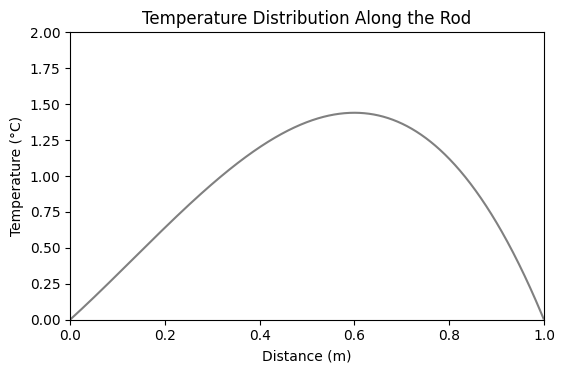

In [28]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Plot the temperature curve on ax_trace
# Create figure and axes
fig, ax_trace = plt.subplots(1, 1, figsize=(6, 4))
plt.tight_layout(pad=3.0)
ax_trace.plot(x_array, y_array, color='gray')
trace_point, = ax_trace.plot([], [], 'bo', markersize=8)
ax_trace.set_xlim(0, totalDistance)
ax_trace.set_ylim(0.0, 2)
ax_trace.set_xlabel('Distance (m)')
ax_trace.set_ylabel('Temperature (°C)')
ax_trace.set_title('Temperature Distribution Along the Rod')

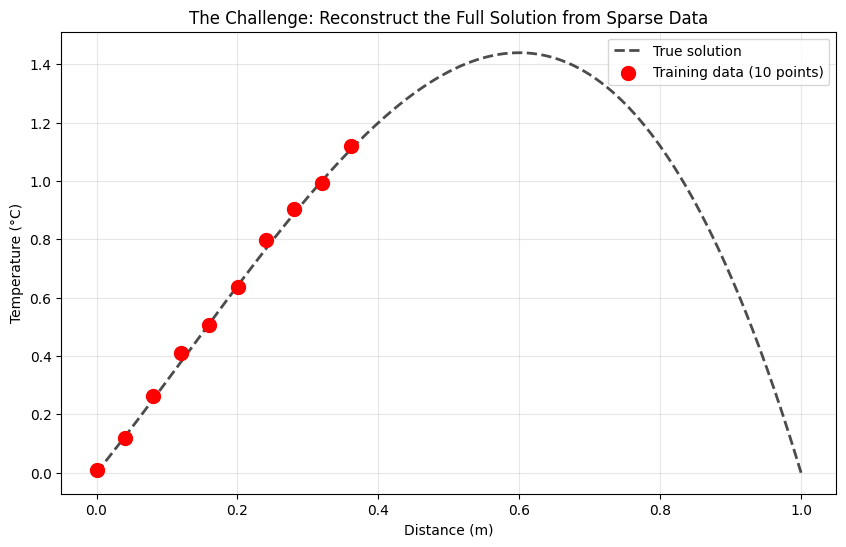

Training data: 10 points with noise level 0.02
Challenge: Can a neural network reconstruct the full solution?


In [29]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Generate sparse training data
n_data = 10  # Only 10 data points!

# Get solution
x_data = np.linspace(0, 0.3607, n_data)
T_data = T_exact(x_data)

# Exact solution
x_exact = np.linspace(0, 1, 500)
T_exact = T_exact(x_exact)

# Add some noise to make it realistic
noise_level = 0.02
T_data_noisy = T_data + noise_level * np.random.normal(0, 1, len(T_data))

# Visualize the sparse data
plt.figure(figsize=(10, 6))
plt.plot(x_exact, T_exact, 'k--', linewidth=2, alpha=0.7, label='True solution')
plt.scatter(x_data, T_data_noisy, color='red', s=100, zorder=5, label=f'Training data ({n_data} points)')
plt.xlabel('Distance (m)')
plt.ylabel('Temperature (°C)')
plt.title('The Challenge: Reconstruct the Full Solution from Sparse Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Training data: {n_data} points with noise level {noise_level}")
print("Challenge: Can a neural network reconstruct the full solution?")

In [30]:
# Derivative of the exact solution for comparison
exact_temp_grad = lambda x: 3 + 4*x - 15*x**2

# Second derivative of the exact solution for comparison
exact_temp_flux = lambda x: 4 - 30*x
    

## Stage 1: The Data-Only Approach

In [32]:
class SimpleNN(nn.Module):
    """Standard feedforward neural network"""
    def __init__(self, hidden_size=32, n_layers=3):
        super().__init__()
        
        layers = []
        layers.append(nn.Linear(1, hidden_size))  # Input: time t
        
        # Hidden layers
        for _ in range(n_layers):
            layers.append(nn.Tanh())  # Smooth activation (important!)
            layers.append(nn.Linear(hidden_size, hidden_size))
        
        layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_size, 1))  # Output: temperature T
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


    # Convert data to PyTorch tensors
x_data_tensor = torch.tensor(x_data.reshape(-1, 1), dtype=torch.float32).to(device)
T_data_tensor = torch.tensor(T_data_noisy.reshape(-1, 1), dtype=torch.float32).to(device)
x_test_tensor = torch.tensor(x_exact.reshape(-1, 1), dtype=torch.float32).to(device)

print("Data shapes:")
print(f"  Training: {x_data_tensor.shape} -> {T_data_tensor.shape}")
print(f"  Testing: {x_test_tensor.shape}")

Data shapes:
  Training: torch.Size([10, 1]) -> torch.Size([10, 1])
  Testing: torch.Size([500, 1])


In [34]:
def train_standard_nn(model, x_data, T_data, epochs=10000, lr=1e-3):
    """Train a standard neural network on data only"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    
    # Training loop
    pbar = tqdm(range(epochs), desc="Training Standard NN")
    for epoch in pbar:
        optimizer.zero_grad()
        # Forward pass
        T_pred = model(x_data)
        # Data loss only
        loss = criterion(T_pred, T_data)
        # Backward pass
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        # Update progress bar with loss information every 100 epochs
        if (epoch + 1) % 100 == 0:
            pbar.set_postfix({'Loss': f'{loss.item():.6f}'})
        
    return losses

# Create and train the standard neural network
standard_nn = SimpleNN().to(device)
losses_standard = train_standard_nn(standard_nn, x_data_tensor, T_data_tensor)
print(f"Final training loss: {losses_standard[-1]:.2e}")

Training Standard NN: 100%|██████████| 10000/10000 [00:11<00:00, 840.29it/s, Loss=0.000199]

Final training loss: 1.99e-04


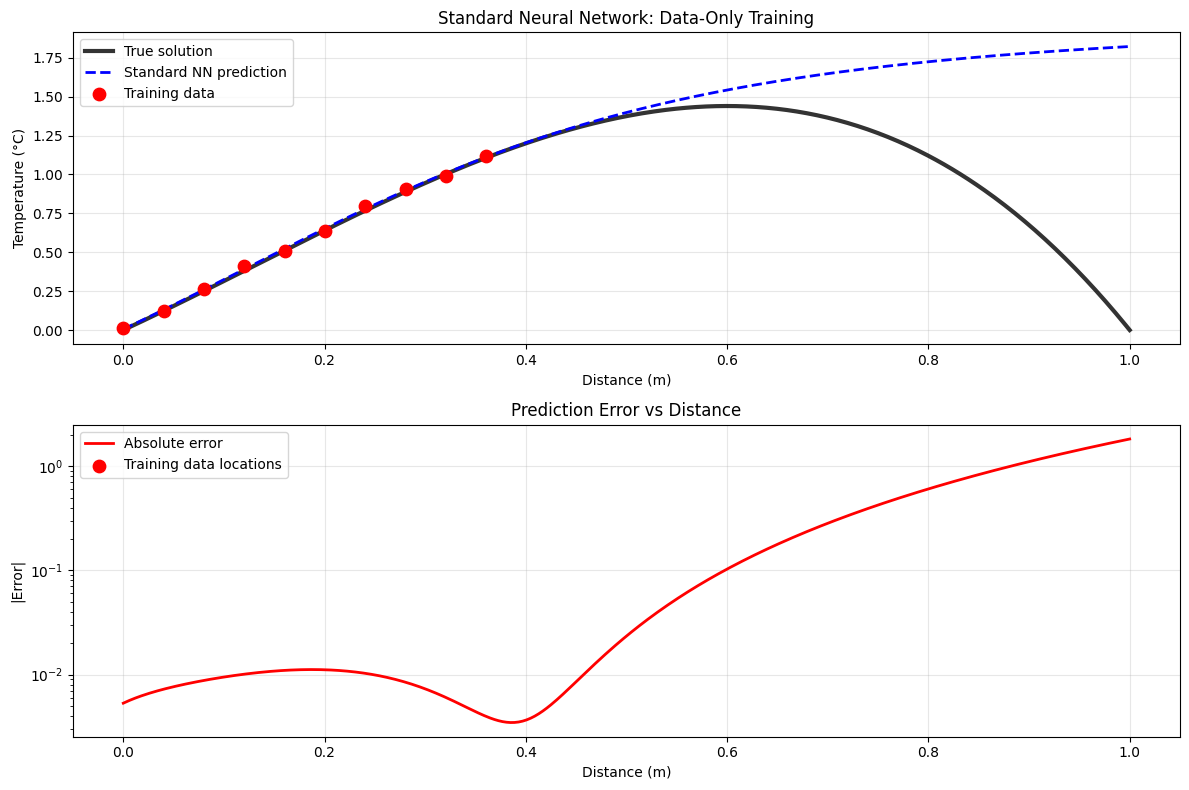

 Standard NN Performance:
  MSE: 0.311566
  Max Error: 1.822499


In [38]:
# Make predictions on the full time domain
with torch.no_grad():
    T_pred_standard = standard_nn(x_test_tensor).detach().cpu().numpy().flatten()

# Visualize the results
plt.figure(figsize=(12, 8))

# Plot 1: Full comparison
plt.subplot(2, 1, 1)
plt.plot(x_exact, T_exact, 'k-', linewidth=3, label='True solution', alpha=0.8)
plt.plot(x_exact, T_pred_standard, 'b--', linewidth=2, label='Standard NN prediction')
plt.scatter(x_data, T_data_noisy, color='red', s=80, zorder=5, label='Training data')
plt.xlabel('Distance (m)')
plt.ylabel('Temperature (°C)')
plt.title('Standard Neural Network: Data-Only Training')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Error analysis
plt.subplot(2, 1, 2)
error = np.abs(T_pred_standard - T_exact)
plt.plot(x_exact, error, 'r-', linewidth=2, label='Absolute error')
plt.scatter(x_data, np.zeros_like(x_data), color='red', s=80, zorder=5, 
            label='Training data locations')
plt.xlabel('Distance (m)')
plt.ylabel('|Error|')
plt.title('Prediction Error vs Distance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

# Compute metrics
mse = np.mean((T_pred_standard - T_exact)**2)
max_error = np.max(np.abs(T_pred_standard - T_exact))

print(f" Standard NN Performance:")
print(f"  MSE: {mse:.6f}")
print(f"  Max Error: {max_error:.6f}")

## Stage 2: Enter Physics-Informed Neural Networks

In [47]:
def physics_loss(model, x_colloc, k, q):
    """Compute the physics-based loss for the steady-state heat conduction problem"""
    # Enable gradients for collocation points
    # Ensure gradients are enabled for input
    x_colloc = x_colloc.clone().detach().to(device).requires_grad_(True)


    # Predict temperature
    T_pred = model(x_colloc)

    # First derivative
    dT_dx = torch.autograd.grad(outputs=T_pred, 
                            inputs=x_colloc, 
                            grad_outputs=torch.ones_like(T_pred), 
                            create_graph=True,
                            retain_graph=True)[0]
    
    # Second derivative
    d2T_dx2 = torch.autograd.grad(outputs=dT_dx, 
                               inputs=x_colloc, 
                               grad_outputs=torch.ones_like(dT_dx), 
                               create_graph=True,
                               retain_graph=True)[0]

    # Evaluate q(x) as a tensor
    q_val = q(x_colloc)

    # Physics residual: d2T/dx2 + q/k = 0
    residual = d2T_dx2 + q_val/k

    # Mean squared residual
    phys_loss = torch.mean(residual**2)
    
    return phys_loss

# Test the physics loss function
test_model = SimpleNN().to(device)
u_test_colloc = torch.linspace(0, 1, 50).reshape(-1, 1).to(device)
test_loss = physics_loss(test_model, u_test_colloc, k, q)

print(f"Physics loss (untrained model): {test_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")

Physics loss (untrained model): 199.538498
This is large since the model hasn't learned the physics yet!


In [ ]:
def boundary_loss(model, x_left, T_left, x_right, T_right):
    """Compute boundary loss for Dirichlet BCs."""
    T_pred_left = model(x_left)
    T_pred_right = model(x_right)
    loss_left = (T_pred_left - T_left)**2
    loss_right = (T_pred_right - T_right)**2
    return torch.mean(loss_left + loss_right)

# Example constants
L = 1.0
T_left = torch.tensor([[0.0]], dtype=torch.float32, device=device)
T_right = torch.tensor([[1.0]], dtype=torch.float32, device=device)

# Boundary positions as tensors
x_left = torch.tensor([[0.0]], dtype=torch.float32, device=device)
x_right = torch.tensor([[L]], dtype=torch.float32, device=device)


# Test the boundary loss function
test_model = SimpleNN().to(device)
test_loss = boundary_loss(test_model, x_left, T_left, x_right, T_right)

print(f"Boundary loss (untrained model): {test_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")

Boundary loss (untrained model): 0.693458
This is large since the model hasn't learned the physics yet!


### Data + PDE Loss

Collocation points: uniformly distributed in [0, 1]
Physics weight λ = 0.0001 (typically much smaller than 1)


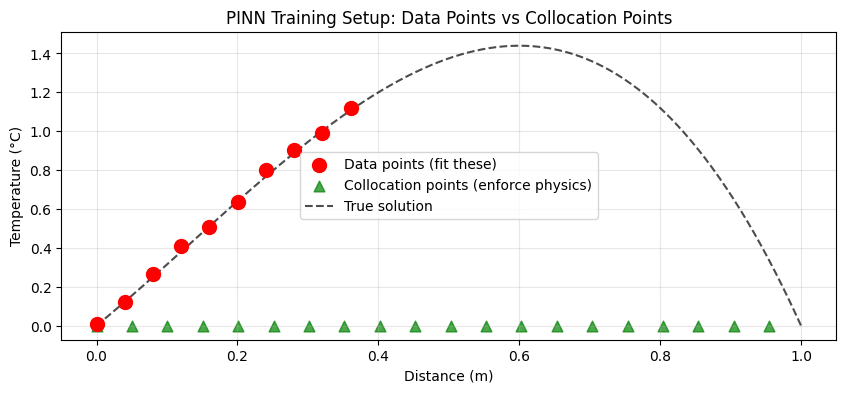

In [48]:
def train_pinn(model, x_data, T_data, x_colloc, k, q, 
               epochs=10000, lr=1e-3, lambda_physics=1e-4):
    """
    Train a Physics-Informed Neural Network
    
    Args:
        model: Neural network
        x_data, T_data: Training data points
        x_colloc: Collocation points for physics
        k, q: Physical parameters
        lambda_physics: Balance parameter between data and physics
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Storage for loss history
    data_losses = []
    physics_losses = []
    total_losses = []
    
    print(f"Training PINN with λ = {lambda_physics}")
    print(f"Data points: {len(x_data)}, Collocation points: {len(x_colloc)}")

    pbar = tqdm(range(epochs), desc="Training PINN")
    for epoch in pbar:
        optimizer.zero_grad()
        
        # Data loss: how well do we fit the measurements?
        T_pred_data = model(x_data)
        loss_data = criterion(T_pred_data, T_data)

        # Physics loss: how well do we satisfy the ODE?
        loss_physics = physics_loss(model, x_colloc, k, q)

        # Total loss: balance data fitting and physics
        total_loss = loss_data + lambda_physics * loss_physics
        
        # Backpropagation
        total_loss.backward()
        optimizer.step()
        
        # Store losses
        data_losses.append(loss_data.item())
        physics_losses.append(loss_physics.item())
        total_losses.append(total_loss.item())
        
        if (epoch + 1) % 2000 == 0:
            pbar.set_postfix({'Loss': f'{loss_data.item():.6f}', 
                              'Physics': f'{loss_physics.item():.6f}', 
                              'Total': f'{total_loss.item():.6f}'})
        
    return data_losses, physics_losses, total_losses


    # Setup for PINN training
n_colloc = 200  # Number of collocation points
x_colloc = torch.linspace(0, 1, n_colloc).to(device).reshape(-1, 1)
x_colloc = torch.linspace(0, 1, n_colloc).reshape(-1, 1)
lambda_physics = 1e-4  # Balance parameter

print(f"Collocation points: uniformly distributed in [0, 1]")
print(f"Physics weight λ = {lambda_physics} (typically much smaller than 1)")

# Visualize training setup
plt.figure(figsize=(10, 4))
plt.scatter(x_data, T_data_noisy, color='red', s=100, zorder=5, label='Data points (fit these)')
plt.scatter(x_colloc.detach().cpu().numpy().flatten()[::10], np.zeros(len(x_colloc[::10])), 
            color='green', marker='^', s=60, alpha=0.7, label='Collocation points (enforce physics)')
plt.plot(x_exact, T_exact, 'k--', alpha=0.7, label='True solution')
plt.xlabel('Distance (m)')
plt.ylabel('Temperature (°C)')
plt.title('PINN Training Setup: Data Points vs Collocation Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
# Create a fresh PINN model
pinn_model = SimpleNN().to(device)

# Train the PINN
data_losses, physics_losses, total_losses = train_pinn(
    pinn_model, x_data_tensor, T_data_tensor, x_colloc, k, q, epochs=10000
)

# Make predictions
with torch.no_grad():
    T_pred_pinn = pinn_model(x_test_tensor).detach().cpu().numpy().flatten()

print(f"PINN Training Complete!")
print(f"Final data loss: {data_losses[-1]:.6f}")
print(f"Final physics loss: {physics_losses[-1]:.6f}")

Training PINN with λ = 0.0001
Data points: 10, Collocation points: 200


Training PINN: 100%|██████████| 10000/10000 [00:42<00:00, 235.60it/s, Loss=0.000184, Physics=0.015090, Total=0.000186]

PINN Training Complete!
Final data loss: 0.000184
Final physics loss: 0.015090


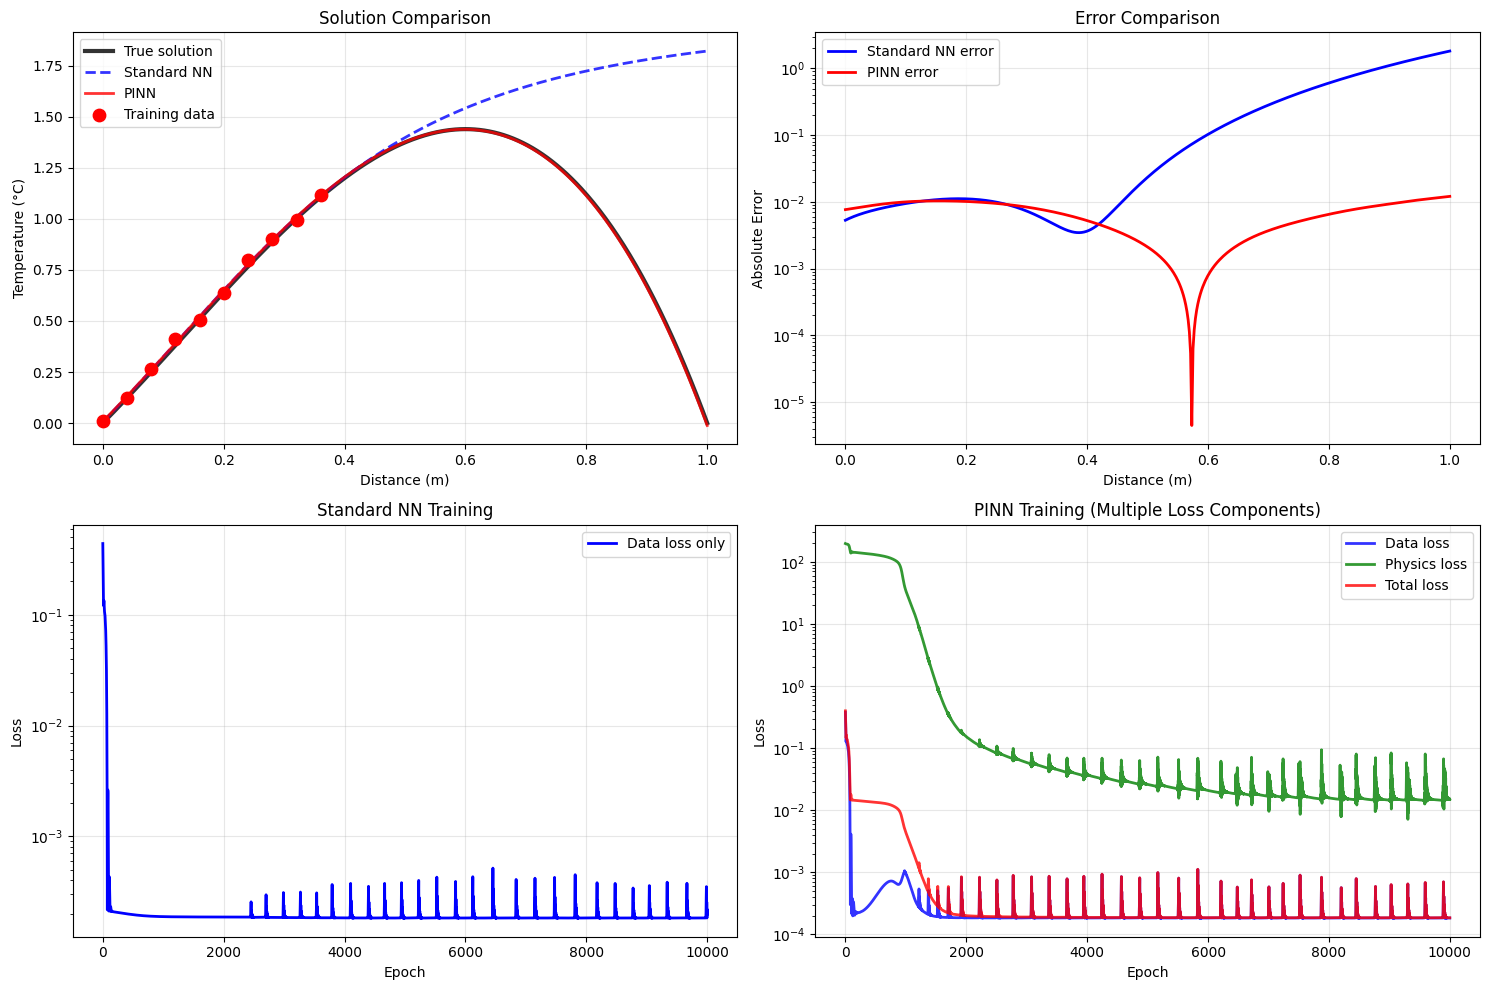

📊 QUANTITATIVE COMPARISON
Metric               Standard NN     PINN            Improvement    
-----------------------------------------------------------------
MSE                  0.311566        0.000055        5675.2         x
Max Error            1.822499        0.012088        150.8          x
✅ PINN is 5675x more accurate!


In [50]:
# Compare Standard NN vs PINN
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Solutions comparison
ax = axes[0, 0]
ax.plot(x_exact, T_exact, 'k-', linewidth=3, label='True solution', alpha=0.8)
ax.plot(x_exact, T_pred_standard, 'b--', linewidth=2, label='Standard NN', alpha=0.8)
ax.plot(x_exact, T_pred_pinn, 'r-', linewidth=2, label='PINN', alpha=0.8)
ax.scatter(x_data, T_data_noisy, color='red', s=80, zorder=5, label='Training data')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Error comparison
ax = axes[0, 1]
error_standard = np.abs(T_pred_standard - T_exact)
error_pinn = np.abs(T_pred_pinn - T_exact)
ax.plot(x_exact, error_standard, 'b-', linewidth=2, label='Standard NN error')
ax.plot(x_exact, error_pinn, 'r-', linewidth=2, label='PINN error')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Comparison')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Loss evolution for Standard NN
ax = axes[1, 0]
ax.plot(losses_standard, 'b-', linewidth=2, label='Data loss only')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Standard NN Training')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Loss evolution for PINN
ax = axes[1, 1]
ax.plot(data_losses, 'b-', linewidth=2, label='Data loss', alpha=0.8)
ax.plot(physics_losses, 'g-', linewidth=2, label='Physics loss', alpha=0.8)
ax.plot(total_losses, 'r-', linewidth=2, label='Total loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('PINN Training (Multiple Loss Components)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
mse_standard = np.mean((T_pred_standard - T_exact)**2)
mse_pinn = np.mean((T_pred_pinn - T_exact)**2)
max_error_standard = np.max(np.abs(T_pred_standard - T_exact))
max_error_pinn = np.max(np.abs(T_pred_pinn - T_exact))

print("📊 QUANTITATIVE COMPARISON")
print("="*50)
print(f"{'Metric':<20} {'Standard NN':<15} {'PINN':<15} {'Improvement':<15}")
print("-"*65)
print(f"{'MSE':<20} {mse_standard:<15.6f} {mse_pinn:<15.6f} {mse_standard/mse_pinn:<15.1f}x")
print(f"{'Max Error':<20} {max_error_standard:<15.6f} {max_error_pinn:<15.6f} {max_error_standard/max_error_pinn:<15.1f}x")

print(f"✅ PINN is {mse_standard/mse_pinn:.0f}x more accurate!")

### PDE and BC Loss

Collocation points: uniformly distributed in [0, 1]


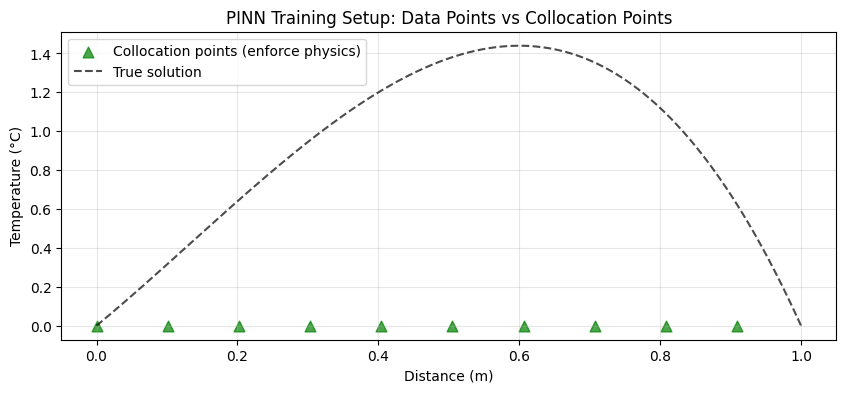

In [94]:
def train_pinn_bc(model, x_colloc, k, q, 
               epochs=10000, lr=1e-3):
    """
    Train a Physics-Informed Neural Network
    
    Args:
        model: Neural network
        x_data, T_data: Training data points
        x_colloc: Collocation points for physics
        k, q: Physical parameters
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Storage for loss history
    bc_losses = []
    physics_losses = []
    total_losses = []
    
    print(f"Collocation points: {len(x_colloc)}")

    pbar = tqdm(range(epochs), desc="Training PINN")
    for epoch in pbar:
        optimizer.zero_grad()

        # Physics loss: how well do we satisfy the ODE?
        loss_physics = physics_loss(model, x_colloc, k, q)

        # BC loss: how well do we satisfy the boundary conditions?
        loss_bc = boundary_loss(model, x_left, T_left, x_right, T_right)

        # Total loss: balance data fitting and physics
        total_loss = 2.5e-6 * loss_physics + loss_bc

        # Backpropagation
        total_loss.backward()
        optimizer.step()
        
        # Store losses
        bc_losses.append(loss_bc.item())
        physics_losses.append(loss_physics.item())
        total_losses.append(total_loss.item())
        
        if (epoch + 1) % 2000 == 0:
            pbar.set_postfix({'Loss': f'{loss_bc.item():.6f}', 
                              'Physics': f'{loss_physics.item():.6f}', 
                              'Total': f'{total_loss.item():.6f}'})
        
    return bc_losses, physics_losses, total_losses


    # Setup for PINN training
n_colloc = 100  # Number of collocation points
x_colloc = torch.linspace(0, 1, n_colloc).to(device).reshape(-1, 1)
x_colloc = torch.linspace(0, 1, n_colloc).reshape(-1, 1)

print(f"Collocation points: uniformly distributed in [0, 1]")

# Visualize training setup
plt.figure(figsize=(10, 4))
plt.scatter(x_colloc.detach().cpu().numpy().flatten()[::10], np.zeros(len(x_colloc[::10])), 
            color='green', marker='^', s=60, alpha=0.7, label='Collocation points (enforce physics)')
plt.plot(x_exact, T_exact, 'k--', alpha=0.7, label='True solution')
plt.xlabel('Distance (m)')
plt.ylabel('Temperature (°C)')
plt.title('PINN Training Setup: Data Points vs Collocation Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [95]:
# Create a fresh PINN model
pinn_model = SimpleNN().to(device)

# Train the PINN
bc_losses, physics_losses, total_losses = train_pinn_bc(
    pinn_model, x_colloc, k, q, epochs=10000
)

# Make predictions
with torch.no_grad():
    T_pred_pinn = pinn_model(x_test_tensor).detach().cpu().numpy().flatten()

print(f"PINN Training Complete!")
print(f"Final boundary loss: {bc_losses[-1]:.6f}")
print(f"Final physics loss: {physics_losses[-1]:.6f}")

Collocation points: 100


Training PINN: 100%|██████████| 10000/10000 [00:49<00:00, 203.02it/s, Loss=0.000000, Physics=42.265682, Total=0.000106]

PINN Training Complete!
Final boundary loss: 0.000000
Final physics loss: 42.265682


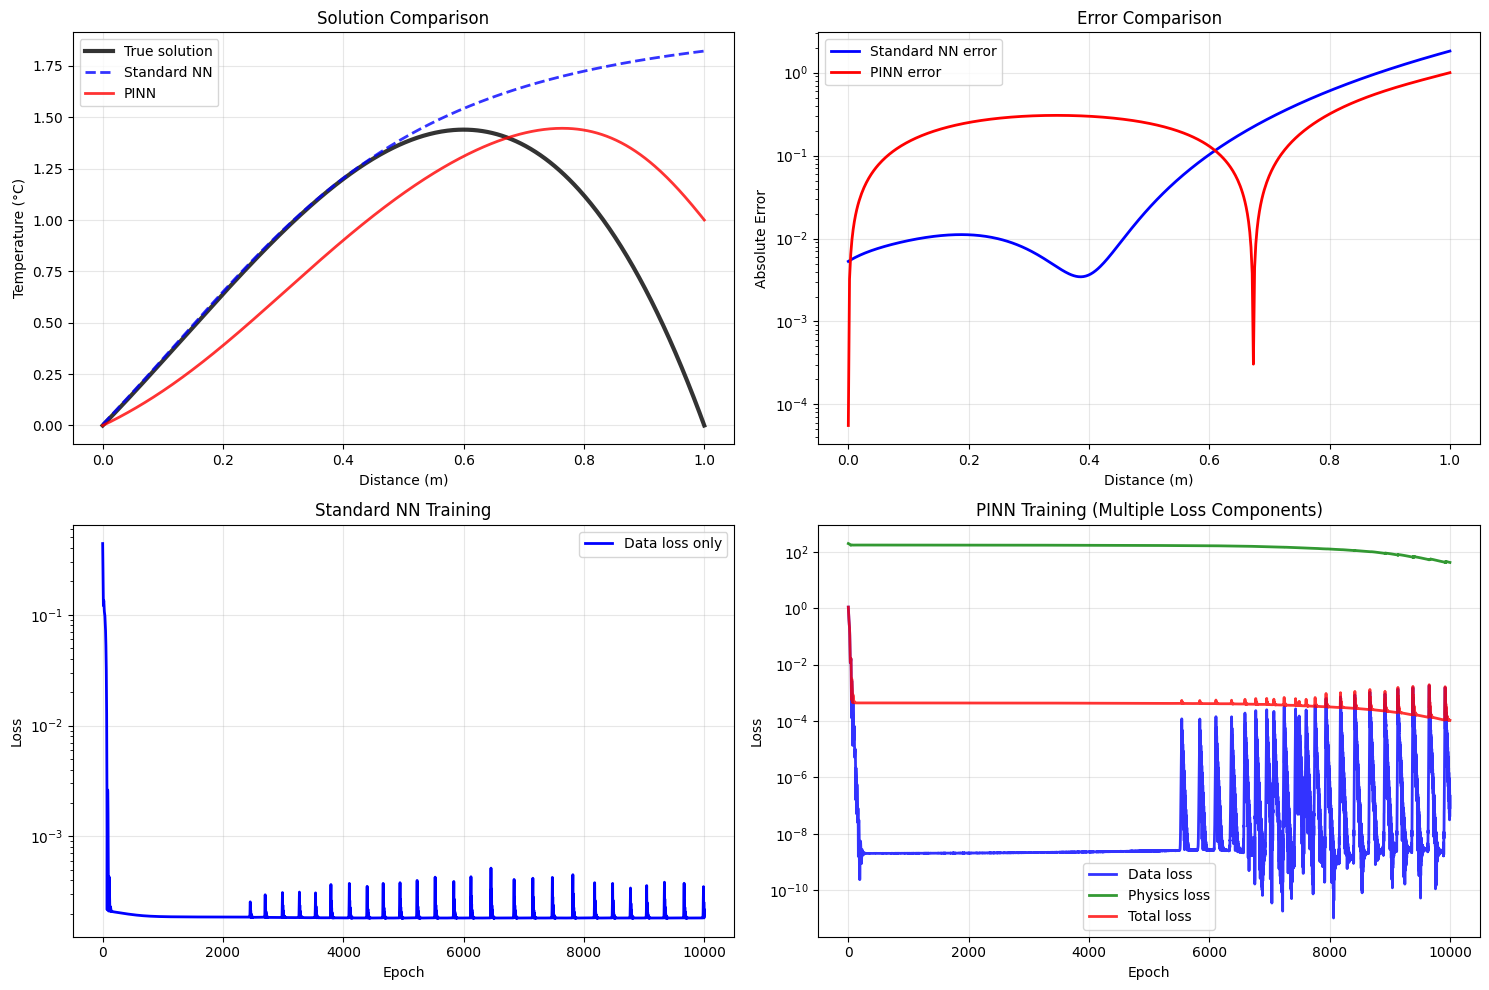

📊 QUANTITATIVE COMPARISON
Metric               Standard NN     PINN            Improvement    
-----------------------------------------------------------------
MSE                  0.311566        0.127804        2.4            x
Max Error            1.822499        1.000235        1.8            x
✅ PINN is 2x more accurate!


In [96]:
# Compare Standard NN vs PINN
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Solutions comparison
ax = axes[0, 0]
ax.plot(x_exact, T_exact, 'k-', linewidth=3, label='True solution', alpha=0.8)
ax.plot(x_exact, T_pred_standard, 'b--', linewidth=2, label='Standard NN', alpha=0.8)
ax.plot(x_exact, T_pred_pinn, 'r-', linewidth=2, label='PINN', alpha=0.8)
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Error comparison
ax = axes[0, 1]
error_standard = np.abs(T_pred_standard - T_exact)
error_pinn = np.abs(T_pred_pinn - T_exact)
ax.plot(x_exact, error_standard, 'b-', linewidth=2, label='Standard NN error')
ax.plot(x_exact, error_pinn, 'r-', linewidth=2, label='PINN error')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Comparison')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Loss evolution for Standard NN
ax = axes[1, 0]
ax.plot(losses_standard, 'b-', linewidth=2, label='Data loss only')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Standard NN Training')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Loss evolution for PINN
ax = axes[1, 1]
ax.plot(bc_losses, 'b-', linewidth=2, label='Data loss', alpha=0.8)
ax.plot(physics_losses, 'g-', linewidth=2, label='Physics loss', alpha=0.8)
ax.plot(total_losses, 'r-', linewidth=2, label='Total loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('PINN Training (Multiple Loss Components)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
mse_standard = np.mean((T_pred_standard - T_exact)**2)
mse_pinn = np.mean((T_pred_pinn - T_exact)**2)
max_error_standard = np.max(np.abs(T_pred_standard - T_exact))
max_error_pinn = np.max(np.abs(T_pred_pinn - T_exact))

print("📊 QUANTITATIVE COMPARISON")
print("="*50)
print(f"{'Metric':<20} {'Standard NN':<15} {'PINN':<15} {'Improvement':<15}")
print("-"*65)
print(f"{'MSE':<20} {mse_standard:<15.6f} {mse_pinn:<15.6f} {mse_standard/mse_pinn:<15.1f}x")
print(f"{'Max Error':<20} {max_error_standard:<15.6f} {max_error_pinn:<15.6f} {max_error_standard/max_error_pinn:<15.1f}x")

print(f"✅ PINN is {mse_standard/mse_pinn:.0f}x more accurate!")

## Observation:
- The Physic based model was 2.4 times better than the standard NN model
- A combination of data and the physics model was the best model, what a 5000 times improvement than a standard NN

# 2: Loss Function Design

Collocation points: uniformly distributed in [0, 1]


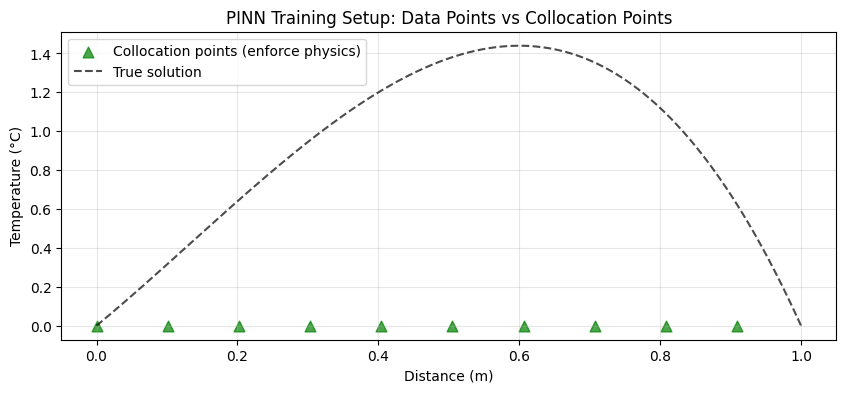

In [106]:
def train_pinn_bc(model, x_colloc, k, q, 
               epochs=10000, lr=1e-3):
    """
    Train a Physics-Informed Neural Network
    
    Args:
        model: Neural network
        x_data, T_data: Training data points
        x_colloc: Collocation points for physics
        k, q: Physical parameters
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Storage for loss history
    bc_losses = []
    physics_losses = []
    total_losses = []
    
    print(f"Collocation points: {len(x_colloc)}")

    pbar = tqdm(range(epochs), desc="Training PINN")

    # Initialize weights
    alpha, beta = 1.0, 1.0

    # Store initial losses after first epoch
    initial_bc_loss, initial_phys_loss = None, None
    for epoch in pbar:
        optimizer.zero_grad()

        # Physics loss: how well do we satisfy the ODE?
        loss_physics = physics_loss(model, x_colloc, k, q)

        # BC loss: how well do we satisfy the boundary conditions?
        loss_bc = boundary_loss(model, x_left, T_left, x_right, T_right)

        # Set initial reference values
        if initial_bc_loss is None:
            initial_bc_loss = loss_bc.item()
            initial_phys_loss = loss_physics.item()

        # Compute adaptive weights
        alpha = initial_bc_loss / (loss_bc.item() + 1e-8)
        beta = initial_phys_loss / (loss_physics.item() + 1e8)

        # Total loss: balance data fitting and physics
        total_loss =  alpha * loss_bc + beta * loss_physics

        # Backpropagation
        total_loss.backward()
        optimizer.step()
        
        # Store losses
        bc_losses.append(loss_bc.item())
        physics_losses.append(loss_physics.item())
        total_losses.append(total_loss.item())
        
        if (epoch + 1) % 2000 == 0:
            pbar.set_postfix({'Loss': f'{loss_bc.item():.6f}', 
                              'Physics': f'{loss_physics.item():.6f}', 
                              'Total': f'{total_loss.item():.6f}'})
        
    return bc_losses, physics_losses, total_losses


    # Setup for PINN training
n_colloc = 100  # Number of collocation points
x_colloc = torch.linspace(0, 1, n_colloc).to(device).reshape(-1, 1)
x_colloc = torch.linspace(0, 1, n_colloc).reshape(-1, 1)

print(f"Collocation points: uniformly distributed in [0, 1]")

# Visualize training setup
plt.figure(figsize=(10, 4))
plt.scatter(x_colloc.detach().cpu().numpy().flatten()[::10], np.zeros(len(x_colloc[::10])), 
            color='green', marker='^', s=60, alpha=0.7, label='Collocation points (enforce physics)')
plt.plot(x_exact, T_exact, 'k--', alpha=0.7, label='True solution')
plt.xlabel('Distance (m)')
plt.ylabel('Temperature (°C)')
plt.title('PINN Training Setup: Data Points vs Collocation Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [107]:
# Create a fresh PINN model
pinn_model = SimpleNN().to(device)

# Train the PINN
bc_losses, physics_losses, total_losses = train_pinn_bc(
    pinn_model, x_colloc, k, q, epochs=10000
)

# Make predictions
with torch.no_grad():
    T_pred_pinn = pinn_model(x_test_tensor).detach().cpu().numpy().flatten()

print(f"PINN Training Complete!")
print(f"Final boundary loss: {bc_losses[-1]:.6f}")
print(f"Final physics loss: {physics_losses[-1]:.6f}")

Collocation points: 100


Training PINN: 100%|██████████| 10000/10000 [00:48<00:00, 205.04it/s, Loss=0.003529, Physics=169.257202, Total=0.976706]

PINN Training Complete!
Final boundary loss: 0.003529
Final physics loss: 169.257202


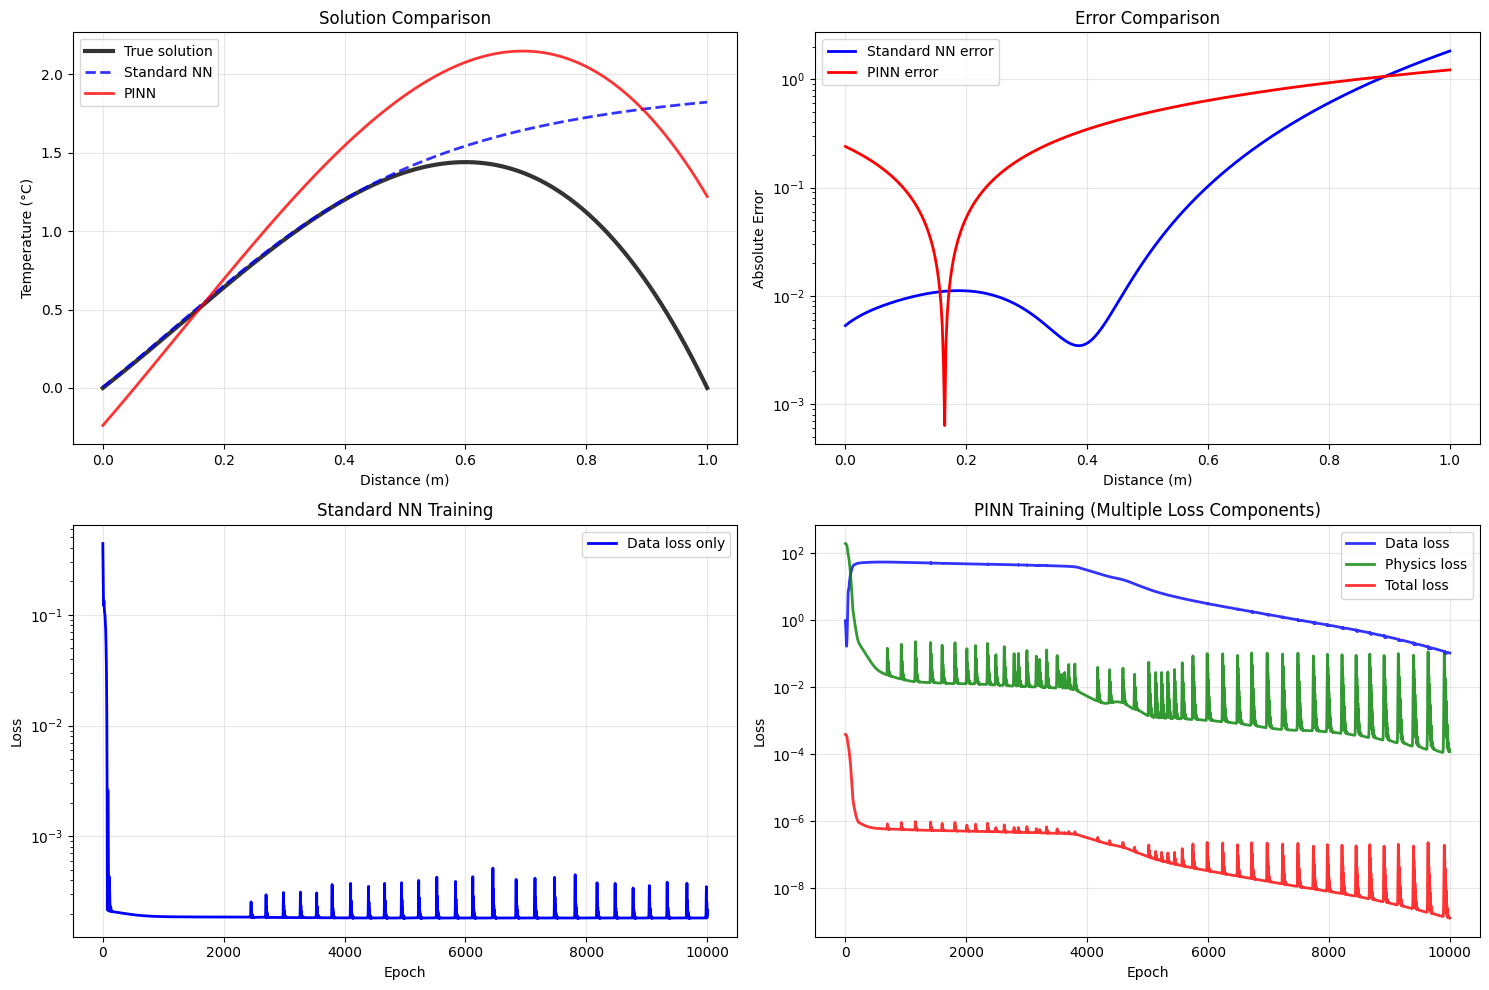

📊 QUANTITATIVE COMPARISON
Metric               Standard NN     PINN            Improvement    
-----------------------------------------------------------------
MSE                  0.311566        0.419335        0.7            x
Max Error            1.822499        1.221059        1.5            x
✅ PINN is 1x more accurate!


In [105]:
# Compare Standard NN vs PINN
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Solutions comparison
ax = axes[0, 0]
ax.plot(x_exact, T_exact, 'k-', linewidth=3, label='True solution', alpha=0.8)
ax.plot(x_exact, T_pred_standard, 'b--', linewidth=2, label='Standard NN', alpha=0.8)
ax.plot(x_exact, T_pred_pinn, 'r-', linewidth=2, label='PINN', alpha=0.8)
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Error comparison
ax = axes[0, 1]
error_standard = np.abs(T_pred_standard - T_exact)
error_pinn = np.abs(T_pred_pinn - T_exact)
ax.plot(x_exact, error_standard, 'b-', linewidth=2, label='Standard NN error')
ax.plot(x_exact, error_pinn, 'r-', linewidth=2, label='PINN error')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Comparison')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Loss evolution for Standard NN
ax = axes[1, 0]
ax.plot(losses_standard, 'b-', linewidth=2, label='Data loss only')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Standard NN Training')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Loss evolution for PINN
ax = axes[1, 1]
ax.plot(bc_losses, 'b-', linewidth=2, label='Data loss', alpha=0.8)
ax.plot(physics_losses, 'g-', linewidth=2, label='Physics loss', alpha=0.8)
ax.plot(total_losses, 'r-', linewidth=2, label='Total loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('PINN Training (Multiple Loss Components)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
mse_standard = np.mean((T_pred_standard - T_exact)**2)
mse_pinn = np.mean((T_pred_pinn - T_exact)**2)
max_error_standard = np.max(np.abs(T_pred_standard - T_exact))
max_error_pinn = np.max(np.abs(T_pred_pinn - T_exact))

print("📊 QUANTITATIVE COMPARISON")
print("="*50)
print(f"{'Metric':<20} {'Standard NN':<15} {'PINN':<15} {'Improvement':<15}")
print("-"*65)
print(f"{'MSE':<20} {mse_standard:<15.6f} {mse_pinn:<15.6f} {mse_standard/mse_pinn:<15.1f}x")
print(f"{'Max Error':<20} {max_error_standard:<15.6f} {max_error_pinn:<15.6f} {max_error_standard/max_error_pinn:<15.1f}x")

print(f"✅ PINN is {mse_standard/mse_pinn:.0f}x more accurate!")

## Observation:
- There wasn't an observed improvement in the model
- It should be noted that the dynamic weights might not be properly implemented

# 3: Variational Formulation [Optional for CE397]

In [ ]:
# ---------- Problem setup ----------
kappa = 0.5  # thermal conductivity (κ)

# q(x) as torch-compatible function
def q_func(x):
    # x is tensor shape (N,1)
    return 15.0 * x - 2.0

# Exact BC values (Dirichlet)
T0 = 0.0
T1 = 0.0
L = 1.0

# ---------- Neural network ----------
class SimpleNN(nn.Module):
    def __init__(self, hidden_size=64, n_layers=3):
        super().__init__()
        layers = [nn.Linear(1, hidden_size), nn.Tanh()]
        for _ in range(n_layers-1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers += [nn.Linear(hidden_size, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# Enforce Dirichlet BCs by construction:
# T(x) = (1-x)*T0 + x*T1 + x*(1-x)*NN(x)
def trial_solution(model, x):
    # x: (N,1) tensor in [0,1]
    nn_out = model(x)
    bc_part = (1.0 - x) * T0 + x * T1
    # factor x*(1-x) ensures zero at x=0 and x=1
    return bc_part + x * (1.0 - x) * nn_out

# ---------- Quadrature (Gauss-Legendre) ----------
def gauss_legendre(n):
    # returns nodes in [0,1] and weights as torch tensors (float32)
    x, w = np.polynomial.legendre.leggauss(n)   # nodes in [-1,1]
    # map to [0,1]
    x_mapped = 0.5 * (x + 1.0)
    w_mapped = 0.5 * w
    return torch.tensor(x_mapped, dtype=torch.float32).reshape(-1,1).to(device), \
           torch.tensor(w_mapped, dtype=torch.float32).reshape(-1,1).to(device)

# ---------- Variational (weak) loss ----------
# choose basis/test functions phi_k(x) = sin(k*pi*x)
def phi_k(x, k):
    # x shape (N,1)
    return torch.sin(k * np.pi * x)

def physics_loss_variational(model, n_testfns=8, quad_pts=32):
    # build quadrature nodes and weights
    x_q, w_q = gauss_legendre(quad_pts)  # x_q (M,1), w_q (M,1)
    x_q = x_q.clone().detach().requires_grad_(True)
    T_pred = trial_solution(model, x_q)  # (M,1)
    # compute dT/dx (first derivative)
    dT_dx = torch.autograd.grad(T_pred, x_q, grad_outputs=torch.ones_like(T_pred),
                                create_graph=True, retain_graph=True)[0]  # (M,1)
    # Assemble integral residuals R_k = ∫ (dT/dx * dφ_k/dx - q/κ * φ_k) dx
    residuals = []
    for k in range(1, n_testfns+1):
        phi = phi_k(x_q, k)                        # (M,1)
        # dφ/dx = k*pi*cos(k*pi*x)
        dphi_dx = (k * np.pi) * torch.cos(k * np.pi * x_q)
        integrand = dT_dx * dphi_dx - (q_func(x_q) / kappa) * phi  # (M,1)
        # integral via quadrature: sum(w * integrand)
        Rk = torch.sum(w_q * integrand)  # scalar
        residuals.append(Rk)
    # Stack residuals and compute mean squared residual (penalize each integral)
    residuals = torch.stack(residuals)  # (n_testfns,)
    loss_var = torch.mean(residuals**2)
    return loss_var

# ---------- Combined losses and training templates ----------
def total_loss_strong(model, x_colloc, alpha=1.0, beta=2.5e-6):
    loss_bc = boundary_loss(model, x_left, T_left, x_right, T_right)  # BCs enforced by construction in trial_solution
    loss_phys = physics_loss(model, x_colloc, kappa, q_func)
    return alpha * loss_bc + beta * loss_phys, loss_bc.detach(), loss_phys.detach()

def total_loss_variational(model, n_testfns=8, quad_pts=32, alpha=1.0, beta=2.5e-6):
    # BCs are satisfied exactly by trial solution, so bc loss = 0
    loss_bc = boundary_loss(model, x_left, T_left, x_right, T_right)
    loss_phys = physics_loss_variational(model, n_testfns=n_testfns, quad_pts=quad_pts)
    return alpha * loss_bc + beta * loss_phys, loss_bc.detach(), loss_phys.detach()

# ---------- Example training loop (choose strong or variational) ----------
def train(model, mode='strong', epochs=10000, lr=1e-3,
          colloc_points=100, n_testfns=8, quad_pts=32, device=device):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # collocation points for strong form
    x_colloc = torch.linspace(0.0, 1.0, colloc_points, device=device).reshape(-1,1)
    pbar = tqdm(range(epochs))
    for epoch in pbar:
        optimizer.zero_grad()
        if mode == 'strong':
            loss, loss_bc, loss_phys = total_loss_strong(model, x_colloc)
        elif mode == 'variational':
            loss, loss_bc, loss_phys = total_loss_variational(model, n_testfns=n_testfns, quad_pts=quad_pts)
        else:
            raise ValueError("mode must be 'strong' or 'variational'")
        loss.backward()
        optimizer.step()
        if epoch % 50 == 0:
            pbar.set_postfix({'loss': loss.item(), 'phys': loss_phys.item()})
    return loss, loss_bc, loss_phys

# ---------- Instantiate and run ----------
model_strong = SimpleNN().to(device)
model_var   = SimpleNN().to(device)

# Train (short runs here; increase epochs as needed)
total_losses_strong, bc_losses_strong, physics_losses_strong = train(model_strong, mode='strong', epochs=10000, lr=1e-3)
total_losses_var, bc_losses_var, physics_losses_var = train(model_var, mode='variational', epochs=10000, lr=1e-3)

# After training, evaluate e.g. L2 norm of PDE residuals and BC errors (BC error should be ~0)
# (You can add plotting of solutions, residuals, etc.)


100%|██████████| 10000/10000 [01:07<00:00, 149.19it/s, loss=4.55e-5, phys=8.47]


In [128]:
# Make predictions
with torch.no_grad():
    T_pred_pinn_str = model_strong(x_test_tensor).detach().cpu().numpy().flatten()
    T_pred_pinn_var = model_var(x_test_tensor).detach().cpu().numpy().flatten()

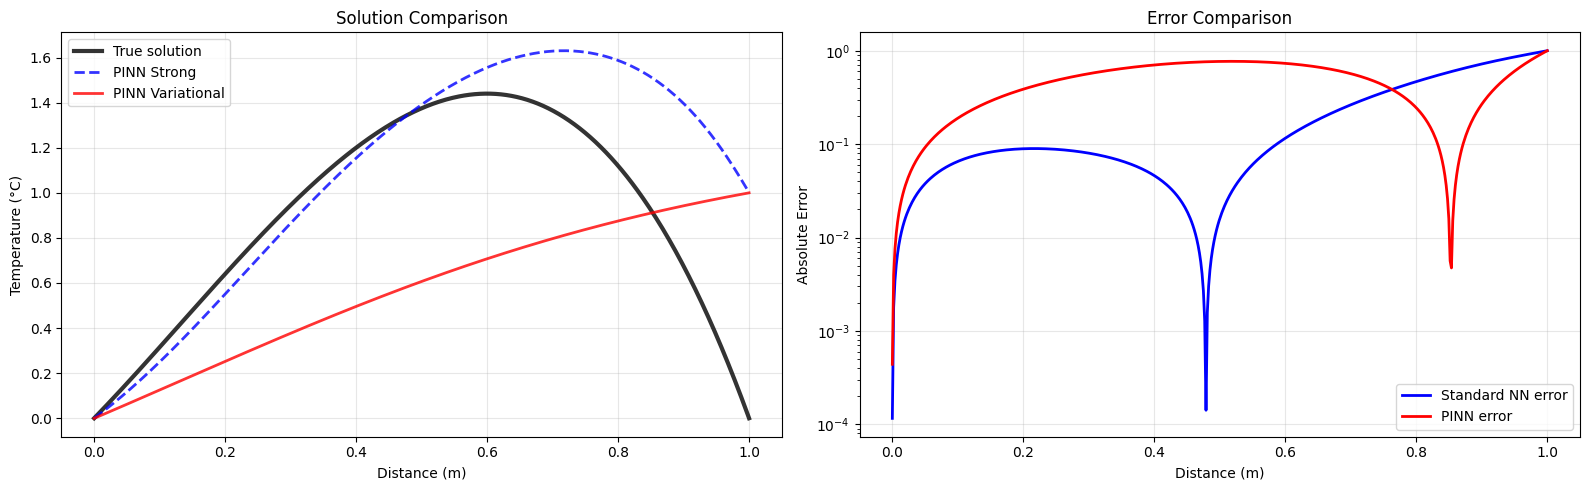

📊 QUANTITATIVE COMPARISON
Metric               Standard NN     PINN            Improvement    
-----------------------------------------------------------------
MSE                  0.311566        0.234634        1.3            x
Max Error            1.822499        0.955713        1.9            x
✅ PINN is 1x more accurate!


In [ ]:
# Compare Standard NN vs PINN
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Plot 1: Solutions comparison
ax = axes[0]
ax.plot(x_exact, T_exact, 'k-', linewidth=3, label='True solution', alpha=0.8)
ax.plot(x_exact, T_pred_pinn_str, 'b--', linewidth=2, label='PINN Strong', alpha=0.8)
ax.plot(x_exact, T_pred_pinn_var, 'r-', linewidth=2, label='PINN Variational', alpha=0.8)
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Error comparison
ax = axes[1]
error_pinn_str = np.abs(T_pred_pinn_str - T_exact)
error_pinn_var = np.abs(T_pred_pinn_var - T_exact)
ax.plot(x_exact, error_pinn_str, 'b-', linewidth=2, label='Standard NN error')
ax.plot(x_exact, error_pinn_var, 'r-', linewidth=2, label='PINN error')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Comparison')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Quantitative comparison
mse_standard = np.mean((T_pred_standard - T_exact)**2)
mse_pinn = np.mean((T_pred_pinn - T_exact)**2)
max_error_standard = np.max(np.abs(T_pred_standard - T_exact))
max_error_pinn = np.max(np.abs(T_pred_pinn - T_exact))

print("📊 QUANTITATIVE COMPARISON")
print("="*50)
print(f"{'Metric':<20} {'Standard NN':<15} {'PINN':<15} {'Improvement':<15}")
print("-"*65)
print(f"{'MSE':<20} {mse_standard:<15.6f} {mse_pinn:<15.6f} {mse_standard/mse_pinn:<15.1f}x")
print(f"{'Max Error':<20} {max_error_standard:<15.6f} {max_error_pinn:<15.6f} {max_error_standard/max_error_pinn:<15.1f}x")

print(f"✅ PINN is {mse_standard/mse_pinn:.0f}x more accurate!")

## Observation:
- The variational formulation had a poor solution compared to the weak form
- However, both solutions are consistent at the boundaries|

# 4. Data-Driven Cross-Section Identification

### Solution Without Noise

In [139]:
u = lambda x: np.sin(2 * np.pi * x)  # Displacement field
p = lambda x: -2 * (3*x**2 - 2*x) * np.pi * np.cos(2 * np.pi * x) + 4 * (x**3 - x**2 + 1) * np.pi**2 * np.sin(2 * np.pi * x)  # Pressure field

EA_exact = lambda x: x**3 - x**2 + 1  # Varying stiffness

In [147]:
class SimpleNN(nn.Module):
    """Standard feedforward neural network"""
    def __init__(self, hidden_size=20, n_layers=3):
        super().__init__()
        
        layers = []
        layers.append(nn.Linear(2, hidden_size))  # Input: spatial coordinate x and displacement u

        # Hidden layers
        for _ in range(n_layers):
            layers.append(nn.Tanh())  # Smooth activation (important!)
            layers.append(nn.Linear(hidden_size, hidden_size))
        
        layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_size, 1))  # Output: stiffness EA
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Exact solution
x_exact = np.linspace(0, 1, 500)
EA_true = EA_exact(x_exact)


    # Convert data to PyTorch tensors
x_test_tensor = torch.tensor(x_exact.reshape(-1, 1), dtype=torch.float32).to(device)

print("Data shapes:")
print(f"  Testing: {x_test_tensor.shape}")

Data shapes:
  Testing: torch.Size([500, 1])


In [167]:
# Function to compute the distributed load p(x)
def compute_p(x):
    term1 = -2 * (3 * x**2 - 2 * x) * torch.pi * torch.cos(2 * torch.pi * x)
    term2 = 4 * (x**3 - x**2 + 1) * torch.pi**2 * torch.sin(2 * torch.pi * x)
    return term1 + term2

# Part b: Formulate the physics-informed loss function
def physics_informed_loss(model, x_colloc):
    # Ensure gradients are enabled for input
    x_colloc = x_colloc.clone().detach().to(device).requires_grad_(True)

    u = torch.sin(2 * torch.pi * x_colloc)

    # Analytical derivatives of u
    du_dx = 2 * torch.pi * torch.cos(2 * torch.pi * x_colloc)
    d2u_dx2 = -4 * torch.pi**2 * torch.sin(2 * torch.pi * x_colloc)

    # Compute EA
    EA = model(torch.cat([x_colloc, u], dim=1))

    # Compute dEA/dx using autograd
    dEA_dx = torch.autograd.grad(EA, x_colloc, grad_outputs=torch.ones_like(EA), create_graph=True)[0]

    # Compute d/dx (EA * du/dx)
    d_dx_term = dEA_dx * du_dx + EA * d2u_dx2

    # Compute p(x)
    p = compute_p(x_colloc)

    # Residual of the PDE
    residual = d_dx_term + p

    # Mean squared error loss
    loss = torch.mean(residual**2)
    return loss

Collocation points: uniformly distributed in [0, 1]


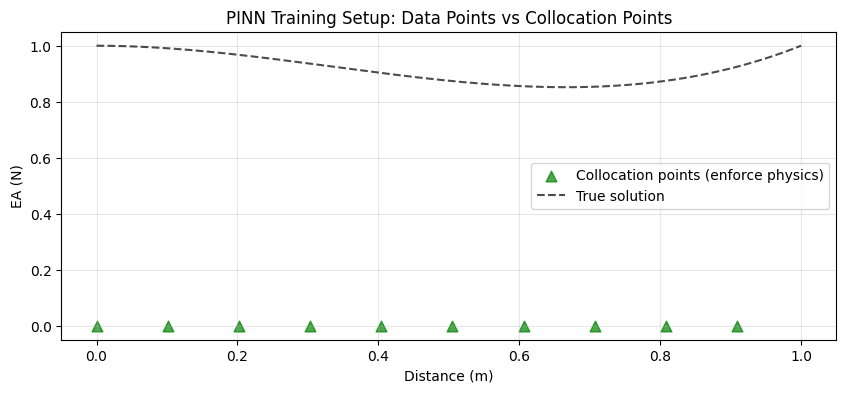

In [168]:
def train_pinn(model, x_colloc, 
               epochs=5000, lr=1e-3):
    """
    Train a Physics-Informed Neural Network
    
    Args:
        model: Neural network
        x_data, T_data: Training data points
        x_colloc: Collocation points for physics
        k, q: Physical parameters
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Storage for loss history
    physics_losses = []
    
    print(f"Collocation points: {len(x_colloc)}")

    pbar = tqdm(range(epochs), desc="Training PINN")
    for epoch in pbar:
        optimizer.zero_grad()

        # Physics loss: how well do we satisfy the ODE?
        loss_physics = physics_informed_loss(model, x_colloc)

        # Backpropagation
        loss_physics.backward()
        optimizer.step()
        
        # Store losses
        physics_losses.append(loss_physics.item())
        
        if (epoch + 1) % 2000 == 0:
            pbar.set_postfix({'Physics': f'{loss_physics.item():.6f}'})

    return physics_losses


    # Setup for PINN training
n_colloc = 100  # Number of collocation points
x_colloc = torch.linspace(0, 1, n_colloc).to(device).reshape(-1, 1)
 
print(f"Collocation points: uniformly distributed in [0, 1]")

# Visualize training setup
plt.figure(figsize=(10, 4))
plt.scatter(x_colloc.detach().cpu().numpy().flatten()[::10], np.zeros(len(x_colloc[::10])), 
            color='green', marker='^', s=60, alpha=0.7, label='Collocation points (enforce physics)')
plt.plot(x_exact, EA_true, 'k--', alpha=0.7, label='True solution')
plt.xlabel('Distance (m)')
plt.ylabel('EA (N)')
plt.title('PINN Training Setup: Data Points vs Collocation Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [171]:
# Create a fresh PINN model
pinn_model = SimpleNN().to(device)

# Train the PINN
physics_losses = train_pinn(
    pinn_model, x_colloc
)

# Make predictions
with torch.no_grad():
    u = torch.sin(2 * torch.pi * x_test_tensor)
    EA_pred_pinn = pinn_model(torch.cat([x_test_tensor, u], dim=1)).detach().cpu().numpy().flatten()

print(f"PINN Training Complete!")
print(f"Final physics loss: {physics_losses[-1]:.6f}")

Collocation points: 100


Training PINN: 100%|██████████| 5000/5000 [00:17<00:00, 278.44it/s, Physics=0.010199]

PINN Training Complete!
Final physics loss: 0.006148


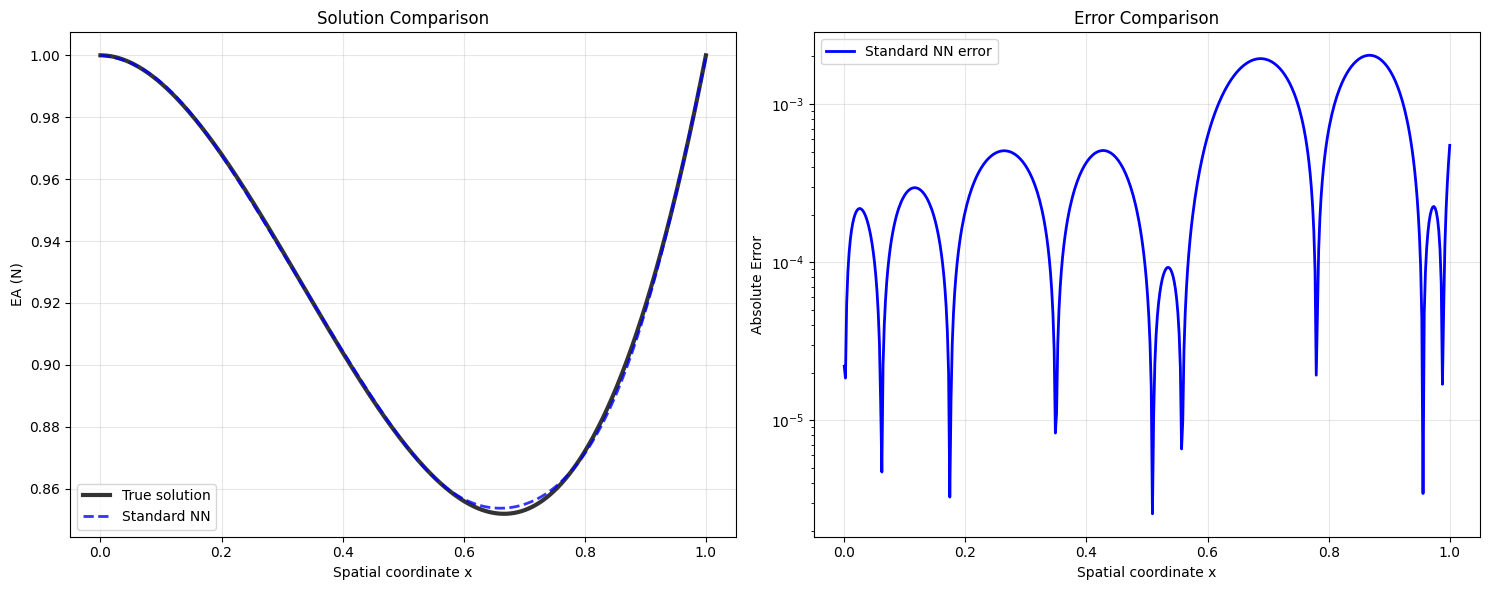

In [175]:
# Compare Standard NN vs PINN
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Solutions comparison
ax = axes[0]
ax.plot(x_exact, EA_true, 'k-', linewidth=3, label='True solution', alpha=0.8)
ax.plot(x_exact, EA_pred_pinn, 'b--', linewidth=2, label='Standard NN', alpha=0.8)
ax.set_xlabel('Spatial coordinate x')
ax.set_ylabel('EA (N)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Error comparison
ax = axes[1]
error_pinn = np.abs(EA_pred_pinn - EA_true)
ax.plot(x_exact, error_pinn, 'b-', linewidth=2, label='Standard NN error')
ax.set_xlabel('Spatial coordinate x')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Comparison')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
mse_standard = np.mean((T_pred_standard - T_exact)**2)
mse_pinn = np.mean((T_pred_pinn - T_exact)**2)
max_error_standard = np.max(np.abs(T_pred_standard - T_exact))
max_error_pinn = np.max(np.abs(T_pred_pinn - T_exact))


### Solution With Noise

In [176]:
# Part b: Formulate the physics-informed loss function
def physics_informed_loss(model, x_colloc):
    noise_std = 0.01 # Standard deviation of noise
    # Ensure gradients are enabled for input
    x_colloc = x_colloc.clone().detach().to(device).requires_grad_(True)

    u_true = torch.sin(2 * torch.pi * x_colloc)

    noise = torch.normal(mean=0.0, std=noise_std, size=u_true.shape, device=x_colloc.device)
    u = u_true + noise

    # Analytical derivatives of u
    du_dx = 2 * torch.pi * torch.cos(2 * torch.pi * x_colloc)
    d2u_dx2 = -4 * torch.pi**2 * torch.sin(2 * torch.pi * x_colloc)

    # Compute EA
    EA = model(torch.cat([x_colloc, u], dim=1))

    # Compute dEA/dx using autograd
    dEA_dx = torch.autograd.grad(EA, x_colloc, grad_outputs=torch.ones_like(EA), create_graph=True)[0]

    # Compute d/dx (EA * du/dx)
    d_dx_term = dEA_dx * du_dx + EA * d2u_dx2

    # Compute p(x)
    p = compute_p(x_colloc)

    # Residual of the PDE
    residual = d_dx_term + p

    # Mean squared error loss
    loss = torch.mean(residual**2)
    return loss

# Create a fresh PINN model
pinn_model = SimpleNN().to(device)

# Train the PINN
physics_losses = train_pinn(
    pinn_model, x_colloc
)

# Make predictions
with torch.no_grad():
    u = torch.sin(2 * torch.pi * x_test_tensor)
    EA_pred_pinn = pinn_model(torch.cat([x_test_tensor, u], dim=1)).detach().cpu().numpy().flatten()

print(f"PINN Training Complete!")
print(f"Final physics loss: {physics_losses[-1]:.6f}")

Collocation points: 100


Training PINN: 100%|██████████| 5000/5000 [00:18<00:00, 266.96it/s, Physics=0.001642]

PINN Training Complete!
Final physics loss: 0.000906


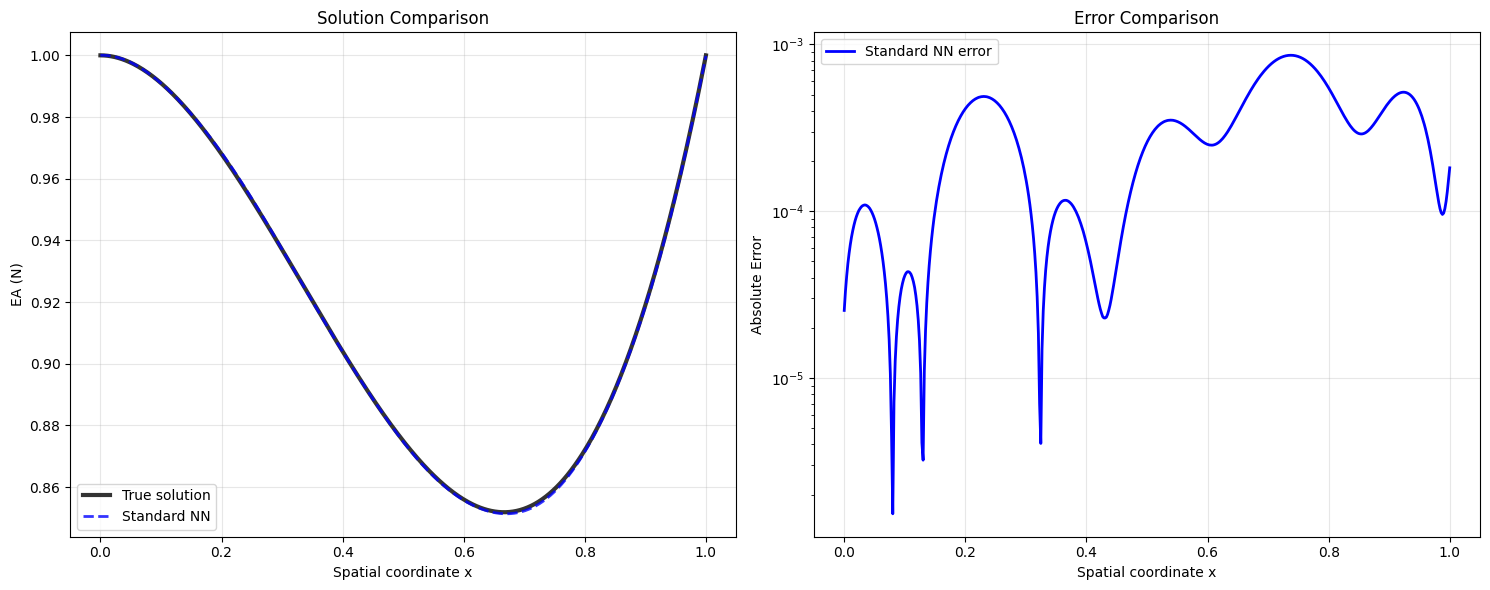

In [177]:
# Compare Standard NN vs PINN
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Solutions comparison
ax = axes[0]
ax.plot(x_exact, EA_true, 'k-', linewidth=3, label='True solution', alpha=0.8)
ax.plot(x_exact, EA_pred_pinn, 'b--', linewidth=2, label='Standard NN', alpha=0.8)
ax.set_xlabel('Spatial coordinate x')
ax.set_ylabel('EA (N)')
ax.set_title('Solution Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Error comparison
ax = axes[1]
error_pinn = np.abs(EA_pred_pinn - EA_true)
ax.plot(x_exact, error_pinn, 'b-', linewidth=2, label='Standard NN error')
ax.set_xlabel('Spatial coordinate x')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Comparison')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
mse_standard = np.mean((T_pred_standard - T_exact)**2)
mse_pinn = np.mean((T_pred_pinn - T_exact)**2)
max_error_standard = np.max(np.abs(T_pred_standard - T_exact))
max_error_pinn = np.max(np.abs(T_pred_pinn - T_exact))


## Observation:
- The PINN has a great fit to the true solution with max error less than 1e-2
- The inclusion of noise to the displacement, further improved the model to a max error less than 1e-3